#Exploring and Visualizing a Simple Dataset

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Dataset Loading**

In [ ]:
iris = load_iris()
x = iris.data
y = iris.target

In [ ]:
iris_df = pd.DataFrame(x, columns=iris.feature_names)
display(iris_df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**Basic Info**

In [ ]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


**Visualization**

**1- Scatter Plot Graph**

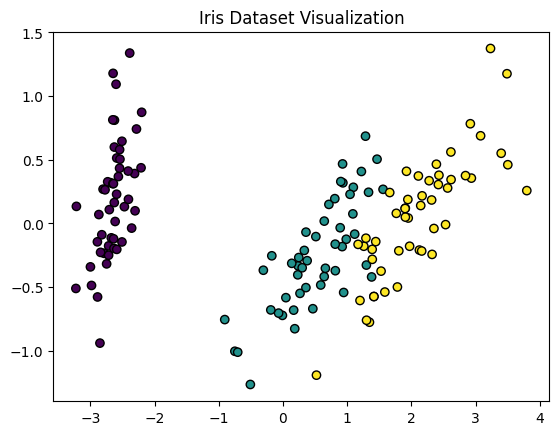

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(x)

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title('Iris Dataset Visualization')
plt.show()

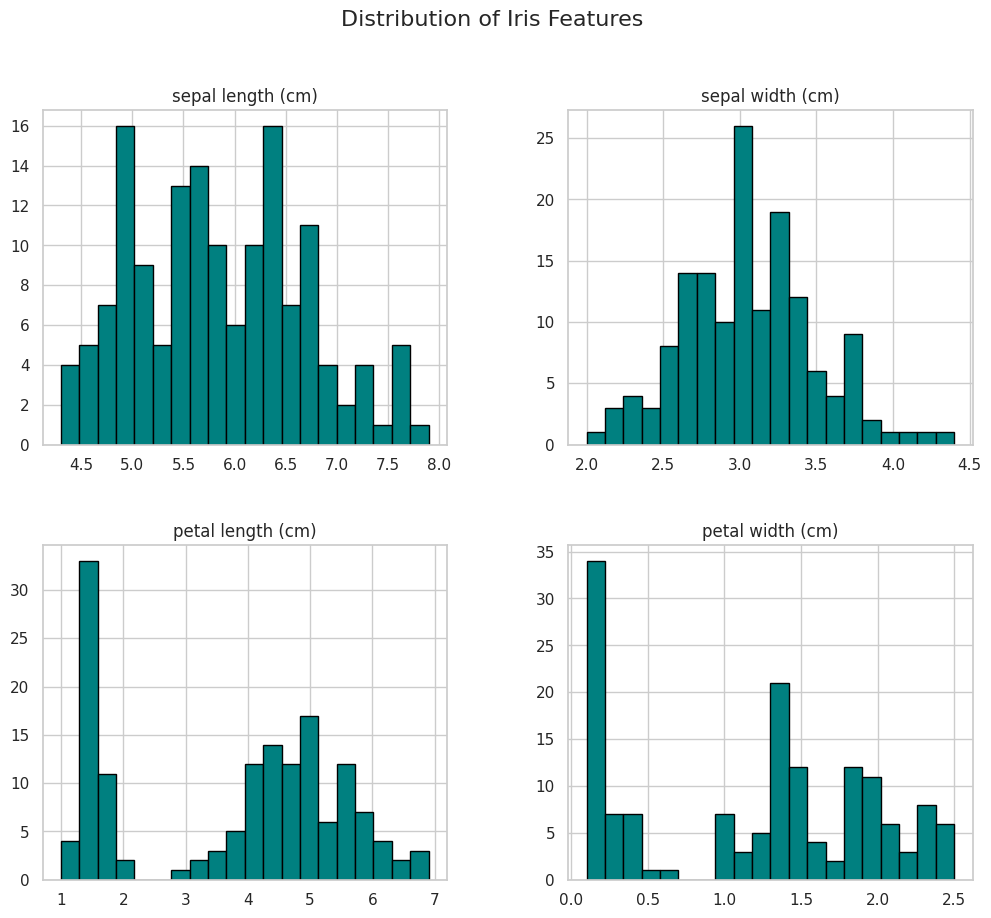

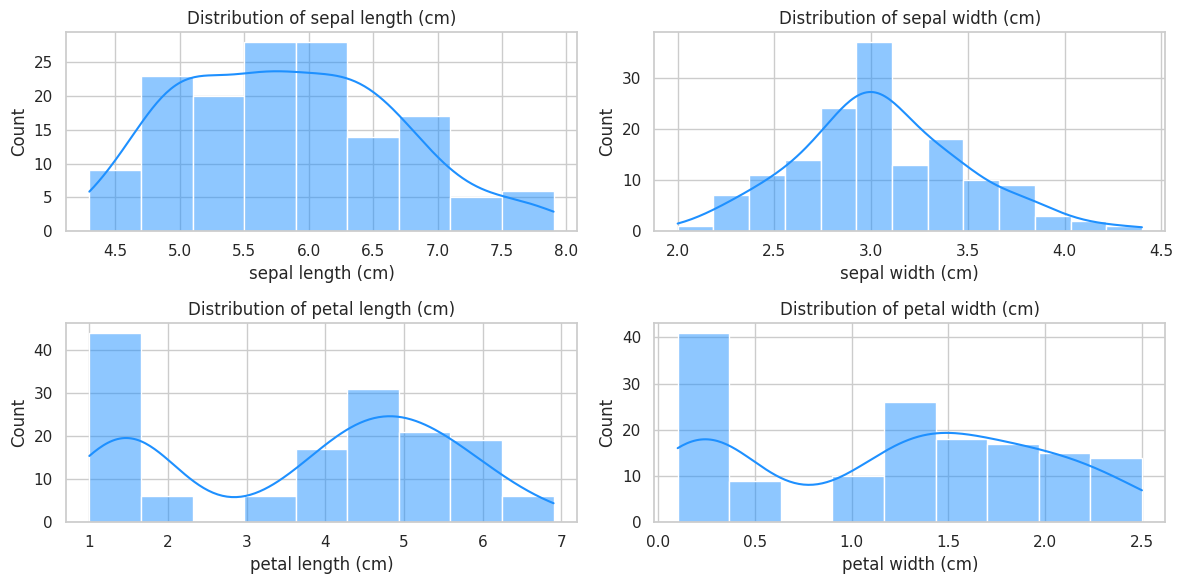

In [ ]:
sns.set_theme(style="whitegrid")

iris_df.hist(bins=20, figsize=(12, 10), color='teal', edgecolor='black')
plt.suptitle("Distribution of Iris Features", fontsize=16)
plt.show()

plt.figure(figsize=(12, 6))
for i, column in enumerate(iris_df.columns):
    plt.subplot(2, 2, i + 1)
    sns.histplot(iris_df[column], kde=True, color="dodgerblue")
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

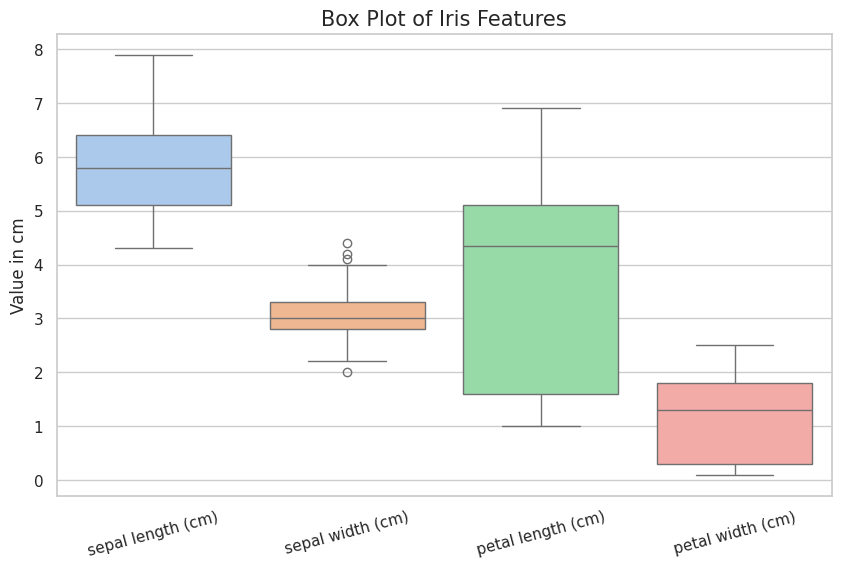

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.boxplot(data=iris_df, palette="pastel")

plt.title("Box Plot of Iris Features", fontsize=15)
plt.ylabel("Value in cm", fontsize=12)
plt.xticks(rotation=15)
plt.show()

**Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 )

**Logistic Regression**

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

**Model Evaluation**

In [ ]:
import numpy as np
y_pred_discrete = np.rint(y_pred).astype(int)
accuracy = accuracy_score(y_test, y_pred_discrete)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00


In [ ]:
print("\n--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))


--- Random Forest Results ---
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

